In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
import seaborn as sns

In [2]:
lv_epochs5 = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/latent_variables_epoch5.csv')
lv_epochs10 = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/latent_variables_epoch10.csv')
lv_epochs5

,LV1,LV2,labels
0,-0.729256,-1.172624,5
1,0.481209,0.035922,4
2,1.338878,-1.702445,1
3,1.087998,-0.135467,3
4,0.226564,-0.218917,5
...,...,...,...
507,1.125864,1.306547,2
508,-2.297976,-0.510080,2
509,-0.211998,-0.660750,2
510,2.514716,0.430717,4


In [3]:
lv_epochs400 = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/VAE/latent_variables_epoch400.csv')

In [4]:
lv_epochs400

,LV1,LV2,labels
0,1.102709,-1.412049,5
1,-2.413440,0.268610,4
2,1.746206,-1.292271,5
3,-0.390458,0.679046,5
4,0.430432,1.789664,1
...,...,...,...
507,-0.013518,-1.189261,5
508,1.128876,0.050697,2
509,0.496028,-0.567352,4
510,-1.021225,0.461225,2


In [5]:
lv_epochs5['labels'] = lv_epochs5['labels'].astype(str)

<Axes: xlabel='LV1', ylabel='LV2'>

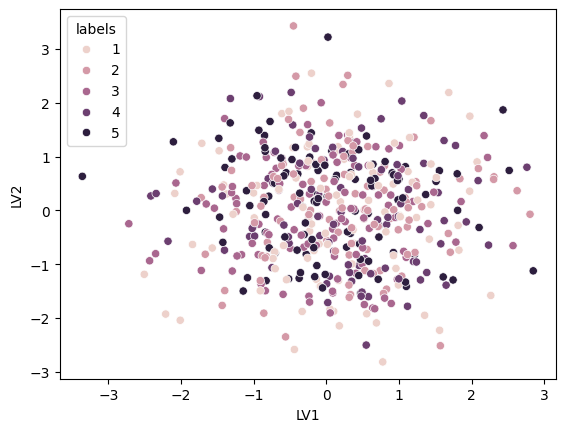

In [6]:
sns.scatterplot(data=lv_epochs400, x='LV1', y='LV2', hue='labels')

Text(0.5, 1.0, 'LV1')

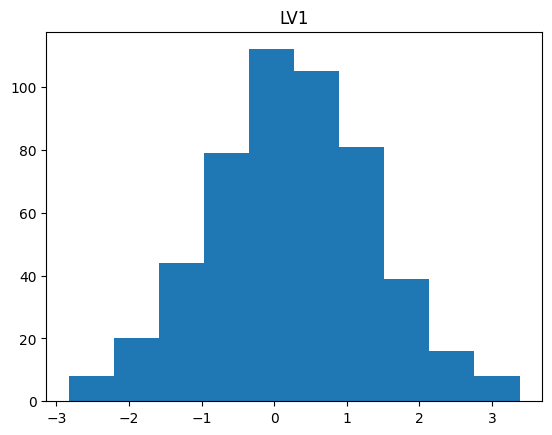

In [7]:
plt.hist(lv_epochs5['LV1'])
plt.title('LV1')

Text(0.5, 1.0, 'LV2')

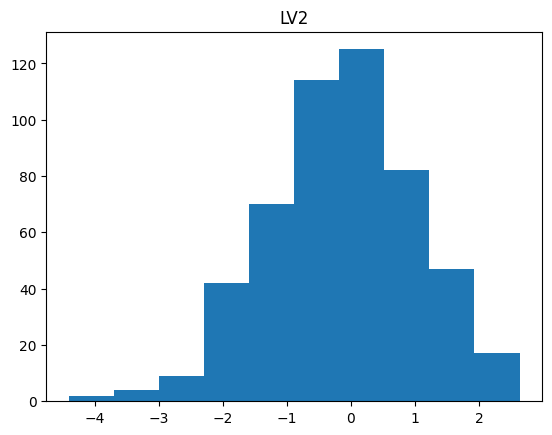

In [8]:
plt.hist(lv_epochs5['LV2'])
plt.title('LV2')

## Testing GMVAE (without conditional layer)

In [9]:
lv_epochs400_gm = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/CGMVAE/latent_variables_epoch200.csv')

<Axes: xlabel='LV1', ylabel='LV2'>

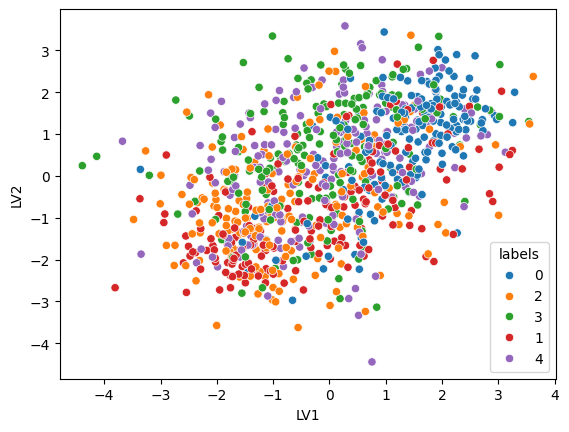

In [10]:
lv_epochs400_gm['labels'] = lv_epochs400_gm['labels'].astype(str)
sns.scatterplot(data=lv_epochs400_gm, x='LV1', y='LV2', hue='labels')

<Axes: xlabel='LV1', ylabel='Density'>

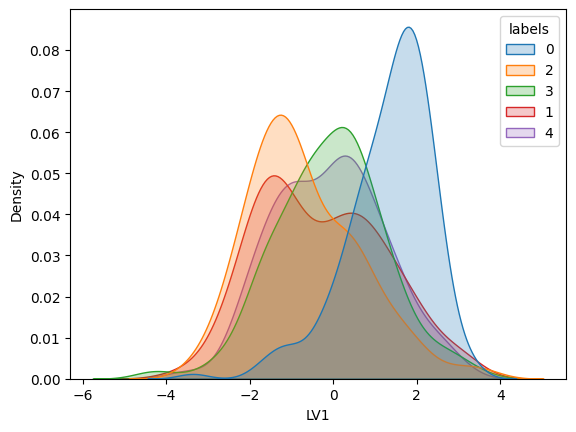

In [11]:
# kernel density plot by label
sns.kdeplot(data=lv_epochs400_gm, x='LV1', hue='labels', fill=True, bw_adjust=1)

<Axes: xlabel='LV2', ylabel='Density'>

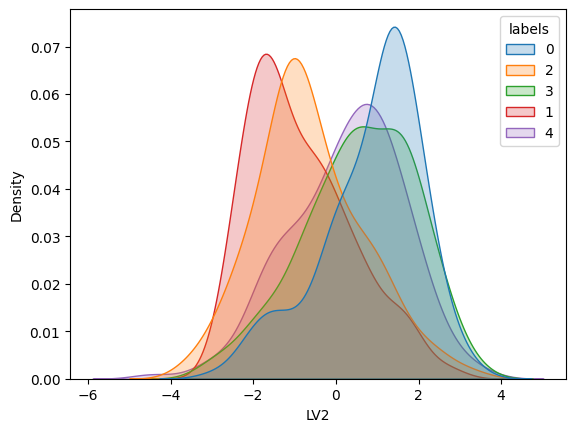

In [12]:
sns.kdeplot(data=lv_epochs400_gm, x='LV2', hue='labels', fill=True, bw_adjust=1)

## Analyzing gaussian mixture

In [13]:
lv_epochs500 = pd.read_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/results_DIET/CGMVAE_box_std3/latent_variables_epoch2000.csv')

In [14]:
gmm_centers = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5_box_small.csv')
gmm_centers

,Unnamed: 0,center1,center2,center3,center4,center5
0,0,-8,-8,0,8,8
1,1,-8,8,0,-8,8


In [15]:
color_map = {
    '0': 'red', 
    '1': 'green', 
    '2': 'purple', 
    '3': 'blue', 
    '4': 'orange'
}

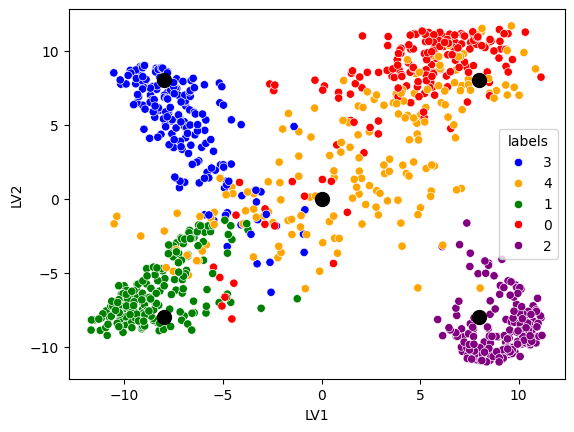

In [16]:
lv_epochs500['labels'] = lv_epochs500['labels'].astype(str)
sns.scatterplot(data=lv_epochs500, x='LV1', y='LV2', hue='labels', palette=color_map)
plt.scatter(gmm_centers.iloc[0, 1:], gmm_centers.iloc[1, 1:], s=100, c='black')

Text(0.5, 1.0, 'KDE plot LV1')

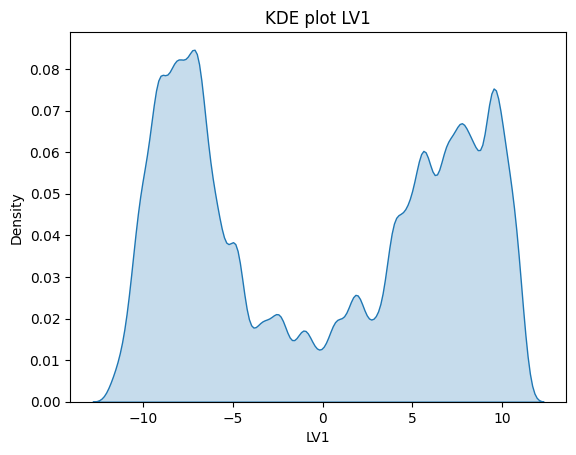

In [17]:
sns.kdeplot(data=lv_epochs500, x='LV1', fill=True, bw_adjust=0.2)
plt.title('KDE plot LV1')

Text(0.5, 1.0, 'LV1')

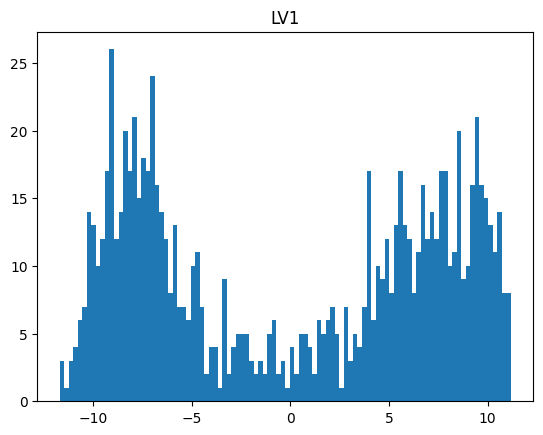

In [18]:
plt.hist(lv_epochs500['LV1'], bins=100)
plt.title('LV1')

Text(0.5, 1.0, 'LV1 colored by conditioning label (diet)')

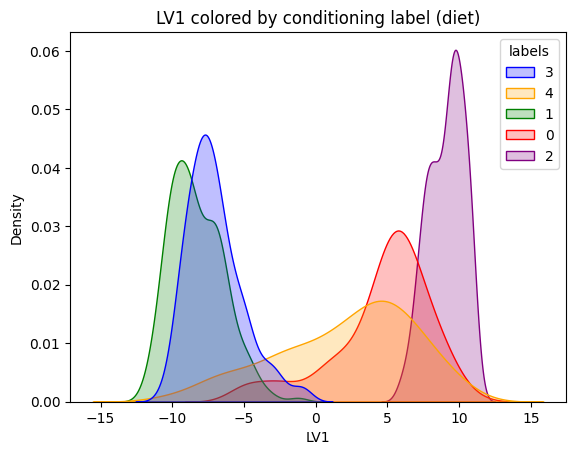

In [19]:
# kernel density plot by label
sns.kdeplot(data=lv_epochs500, x='LV1', hue='labels', fill=True, bw_adjust=1, palette=color_map)
plt.title('LV1 colored by conditioning label (diet)')

Text(0.5, 1.0, 'KDE plot LV2')

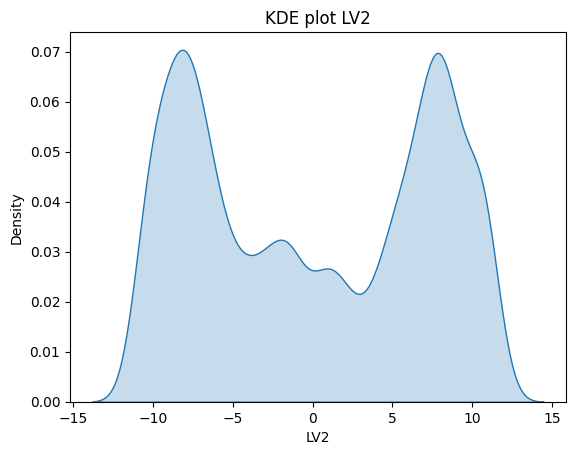

In [20]:
sns.kdeplot(data=lv_epochs500, x='LV2', fill=True, bw_adjust=0.5)
plt.title('KDE plot LV2')

Text(0.5, 1.0, 'LV2')

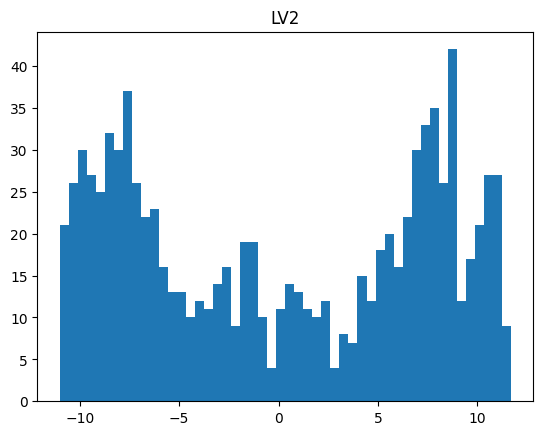

In [21]:
plt.hist(lv_epochs500['LV2'], bins=50)
plt.title('LV2')

Text(0.5, 1.0, 'LV2 colored by conditioning label (diet)')

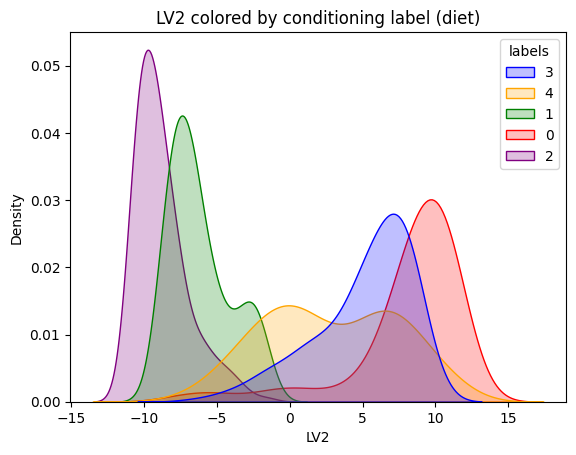

In [22]:
sns.kdeplot(data=lv_epochs500, x='LV2', hue='labels', fill=True, bw_adjust=1.2, palette=color_map)
plt.title('LV2 colored by conditioning label (diet)')

## Plotting latent space with CFC data 

In [23]:
lv_epochs500

,LV1,LV2,labels,mouse_ids
0,-5.807242,1.797897,3,DO-1D-3040
1,5.303995,2.054742,4,DO-AL-0182
2,-6.589289,-2.540444,1,DO-20-1036
3,6.849869,9.741388,0,DO-40-2114
4,-8.559358,7.592325,3,DO-1D-3064
...,...,...,...,...
932,-8.379555,-7.046987,1,DO-20-1069
933,-8.671330,-6.747914,1,DO-20-1041
934,-7.984651,-5.861492,1,DO-20-1037
935,9.964693,-8.908081,2,DO-2D-4094


In [24]:
#latent_variables_cfc = pd.read_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/cfc/latent_variables_10000epochs.csv')
cfc = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/cfc_data_filtered.csv')
cfc_latent_merged = pd.merge(lv_epochs500, cfc, left_on='mouse_ids', right_on='Mouse.ID')

In [25]:
cfc_latent_merged

,LV1,LV2,labels,mouse_ids,Diet,Mouse.ID,CFC.24mo.Average
0,-5.807242,1.797897,3,DO-1D-3040,1D,DO-1D-3040,81.73
1,9.440753,-10.042184,2,DO-2D-4102,2D,DO-2D-4102,57.56
2,9.768505,7.538910,4,DO-AL-0107,AL,DO-AL-0107,38.18
3,10.165072,-9.785585,2,DO-2D-4183,2D,DO-2D-4183,58.98
4,10.597219,-8.430428,2,DO-2D-4147,2D,DO-2D-4147,86.89
...,...,...,...,...,...,...,...
499,-7.506844,7.852673,3,DO-1D-3097,1D,DO-1D-3097,19.16
500,-8.671330,-6.747914,1,DO-20-1041,20,DO-20-1041,34.89
501,-7.984651,-5.861492,1,DO-20-1037,20,DO-20-1037,92.00
502,9.964693,-8.908081,2,DO-2D-4094,2D,DO-2D-4094,65.38


Text(0.5, 1.0, '2D Latent space colored by CFC score')

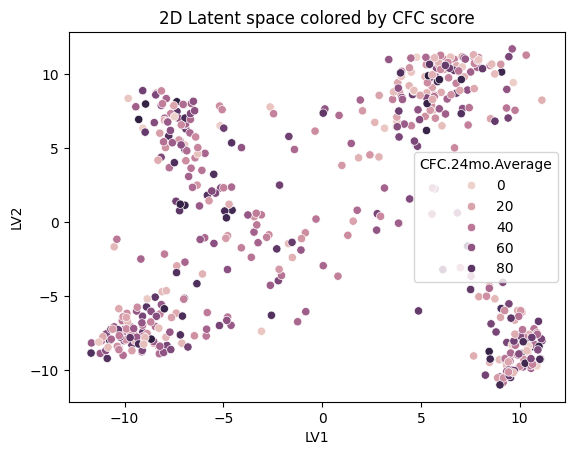

In [26]:
sns.scatterplot(data=cfc_latent_merged, x='LV1', y='LV2', hue='CFC.24mo.Average')
plt.title('2D Latent space colored by CFC score')
#plt.scatter(gmm_centers.iloc[0, 1:], gmm_centers.iloc[1, 1:], s=100, c='black')

In [27]:
color_map_diet = {
    '40': 'red', 
    '20': 'green', 
    '2D': 'purple', 
    '1D': 'blue', 
    'AL': 'orange'
}

/var/folders/9x/6ggst85x2311z107r2nwhbdc0000gn/T/ipykernel_3095/3750440136.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=cfc_latent_merged['Diet'], y=cfc_latent_merged['CFC.24mo.Average'], data=cfc_latent_merged, palette=color_map_diet)


<Axes: xlabel='Diet', ylabel='CFC.24mo.Average'>

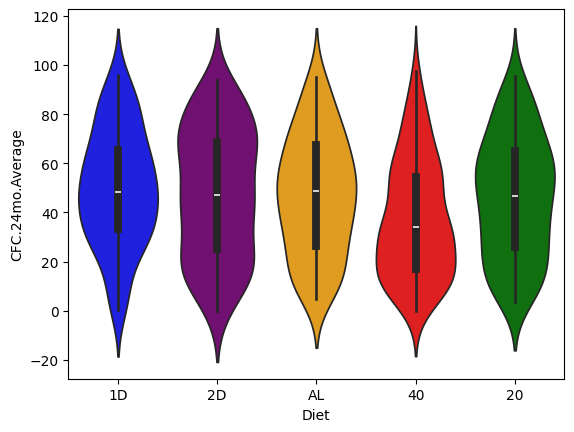

In [28]:
sns.violinplot(x=cfc_latent_merged['Diet'], y=cfc_latent_merged['CFC.24mo.Average'], data=cfc_latent_merged, palette=color_map_diet)

/var/folders/9x/6ggst85x2311z107r2nwhbdc0000gn/T/ipykernel_3095/60561036.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cfc_latent_merged['Diet'], y=cfc_latent_merged['CFC.24mo.Average'], data=cfc_latent_merged, palette=color_map_diet)


Text(0.5, 1.0, 'Distribution of CFC scores across diets')

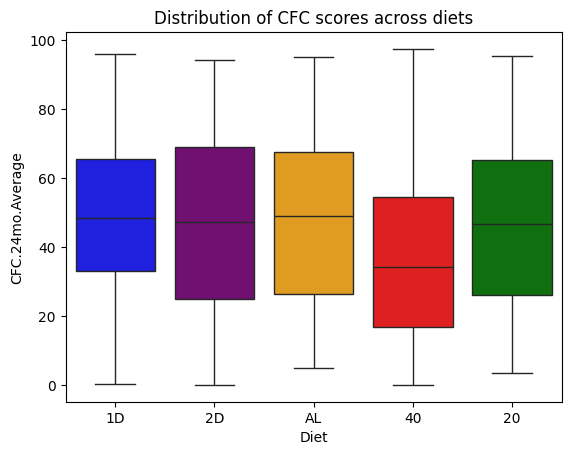

In [29]:
sns.boxplot(x=cfc_latent_merged['Diet'], y=cfc_latent_merged['CFC.24mo.Average'], data=cfc_latent_merged, palette=color_map_diet)
plt.title('Distribution of CFC scores across diets')

In [30]:
ymaze_speed_data_cleaned = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/ymaze_speed_data_cleaned.csv')
ymaze_speed_latent_merged = pd.merge(lv_epochs500, ymaze_speed_data_cleaned, left_on='mouse_ids', right_on='Mouse.ID')

Text(0.5, 1.0, '2D Latent space colored by ymaze speed score')

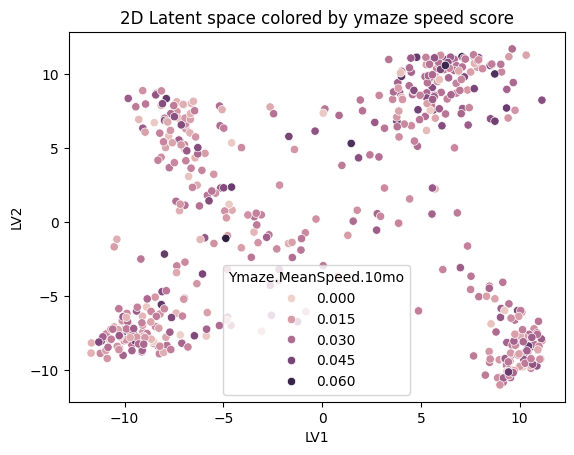

In [31]:
sns.scatterplot(ymaze_speed_latent_merged, x='LV1', y='LV2', hue='Ymaze.MeanSpeed.10mo')
plt.title('2D Latent space colored by ymaze speed score')

/var/folders/9x/6ggst85x2311z107r2nwhbdc0000gn/T/ipykernel_3095/4063259262.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=ymaze_speed_latent_merged['Diet'], y=ymaze_speed_latent_merged['Ymaze.MeanSpeed.10mo'], data=ymaze_speed_latent_merged, palette=color_map_diet)


Text(0.5, 1.0, 'Distribution of Ymaze speed across diets')

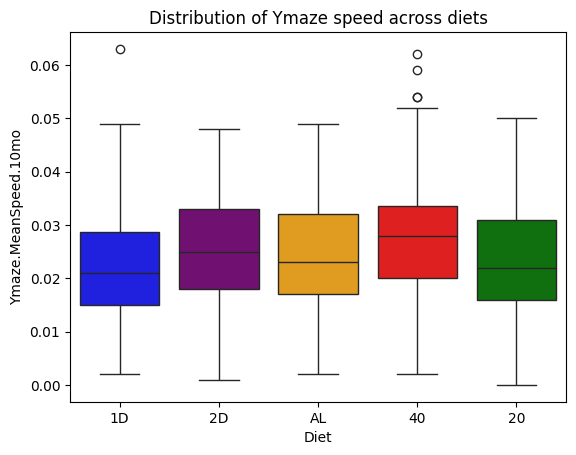

In [32]:
sns.boxplot(x=ymaze_speed_latent_merged['Diet'], y=ymaze_speed_latent_merged['Ymaze.MeanSpeed.10mo'], data=ymaze_speed_latent_merged, palette=color_map_diet)
plt.title('Distribution of Ymaze speed across diets')

In [33]:
ymaze_distance_data_cleaned = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/ymaze_distance_data_cleaned.csv')
ymaze_distance_latent_merged = pd.merge(lv_epochs500, ymaze_distance_data_cleaned, left_on='mouse_ids', right_on='Mouse.ID')

Text(0.5, 1.0, '2D Latent space colored by ymaze distance score')

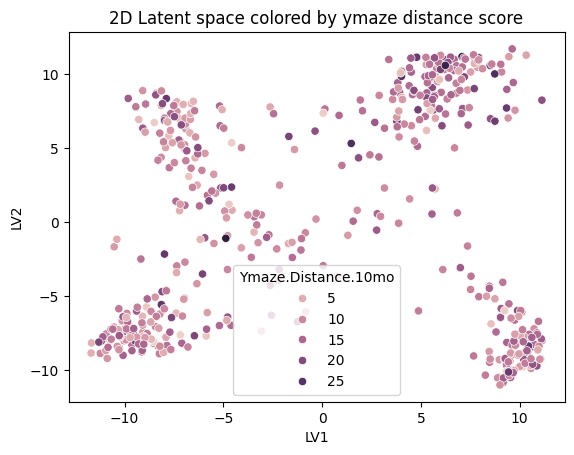

In [34]:
sns.scatterplot(ymaze_distance_latent_merged, x='LV1', y='LV2', hue='Ymaze.Distance.10mo')
plt.title('2D Latent space colored by ymaze distance score')

In [35]:
ymaze_alt = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/ymaze_alt_data_cleaned.csv')
ymaze_alt_latent_merged = pd.merge(lv_epochs500, ymaze_alt, left_on='mouse_ids', right_on='Mouse.ID')
ymaze_alt_latent_merged

,LV1,LV2,labels,mouse_ids,Diet,Mouse.ID,SpontaneousAlternations.10mo
0,-5.807242,1.797897,3,DO-1D-3040,1D,DO-1D-3040,15.0
1,9.440753,-10.042184,2,DO-2D-4102,2D,DO-2D-4102,15.0
2,9.768505,7.538910,4,DO-AL-0107,AL,DO-AL-0107,10.0
3,10.165072,-9.785585,2,DO-2D-4183,2D,DO-2D-4183,0.0
4,10.597219,-8.430428,2,DO-2D-4147,2D,DO-2D-4147,17.0
...,...,...,...,...,...,...,...
499,-7.506844,7.852673,3,DO-1D-3097,1D,DO-1D-3097,12.0
500,-8.671330,-6.747914,1,DO-20-1041,20,DO-20-1041,7.0
501,-7.984651,-5.861492,1,DO-20-1037,20,DO-20-1037,15.0
502,9.964693,-8.908081,2,DO-2D-4094,2D,DO-2D-4094,9.0


Text(0.5, 1.0, '2D Latent space colored by num ymaze spontaneous alternations')

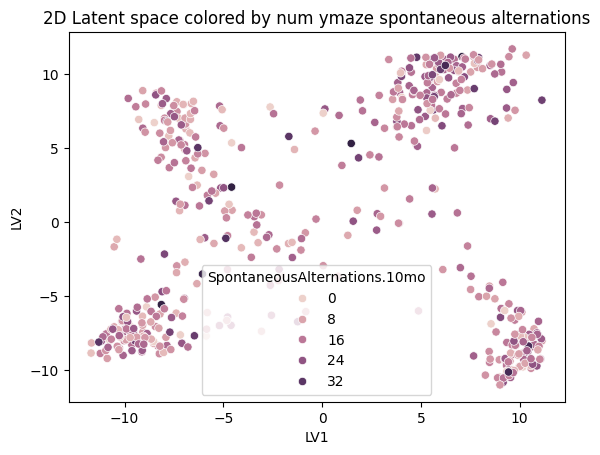

In [36]:
sns.scatterplot(ymaze_alt_latent_merged, x='LV1', y='LV2', hue='SpontaneousAlternations.10mo')
plt.title('2D Latent space colored by num ymaze spontaneous alternations')

/var/folders/9x/6ggst85x2311z107r2nwhbdc0000gn/T/ipykernel_3095/2302326714.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=ymaze_alt_latent_merged['Diet'], y=ymaze_alt_latent_merged['SpontaneousAlternations.10mo'], data=ymaze_alt_latent_merged, palette=color_map_diet)


Text(0.5, 1.0, 'Distribution of Ymaze spontaneous alternations across diets')

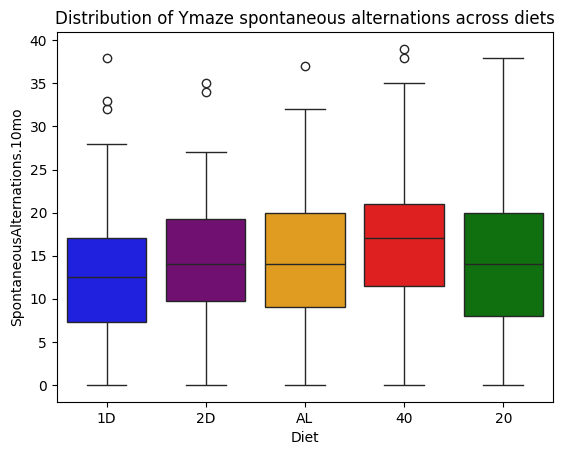

In [37]:
sns.boxplot(x=ymaze_alt_latent_merged['Diet'], y=ymaze_alt_latent_merged['SpontaneousAlternations.10mo'], data=ymaze_alt_latent_merged, palette=color_map_diet)
plt.title('Distribution of Ymaze spontaneous alternations across diets')

## Analysis with Gaussian Mixture gmm_centers_5_new.csv

In [38]:
import matplotlib.pyplot as plt
from scipy.stats import norm

In [39]:
lv_epochs200 = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/CGMVAE/latent_variables_epoch1000.csv')
lv_epochs200

,LV1,LV2,labels
0,-0.577979,0.236226,3
1,-2.031262,-0.965379,2
2,-2.092094,-1.885342,1
3,-1.641962,-1.311303,1
4,-1.349735,0.614059,3
...,...,...,...
932,0.174373,-0.908072,2
933,0.944234,-1.752724,1
934,-1.037076,2.014442,3
935,-0.534360,0.222044,3


In [40]:
label1 = lv_epochs200[lv_epochs200['labels'] == 0]
label2 = lv_epochs200[lv_epochs200['labels'] == 1]
label3 = lv_epochs200[lv_epochs200['labels'] == 2]
label4 = lv_epochs200[lv_epochs200['labels'] == 3]
label5 = lv_epochs200[lv_epochs200['labels'] == 4]

mean label 1:1.954601679120879, std label 1: 0.3540961986992352
mean label 2:-0.5739635529899471, std label 2: 1.1337341848348463
mean label 3:-1.2536561513331579, std label 3: 0.8471510296251231
mean label 4:-0.7994809950212766, std label 4: 0.911511234377367
mean label 5:0.8638184640851064, std label 5: 0.723933991109741


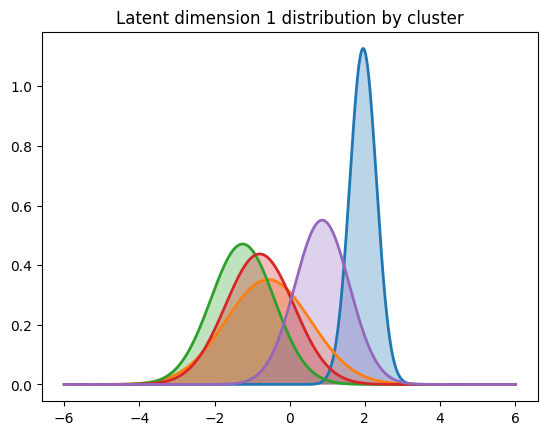

In [41]:
cluster_params_lv1 = {
    '1': {'mean': np.mean(label1['LV1']), 'variance': np.std(label1['LV1'])}, 
    '2': {'mean': np.mean(label2['LV1']), 'variance': np.std(label2['LV1'])}, 
    '3': {'mean': np.mean(label3['LV1']), 'variance': np.std(label3['LV1'])},
    '4': {'mean': np.mean(label4['LV1']), 'variance': np.std(label4['LV1'])},
    '5': {'mean': np.mean(label5['LV1']), 'variance': np.std(label5['LV1'])},
}

all_means = [p['mean'] for p in cluster_params_lv1.values()]
all_stds = [p['variance'] for p in cluster_params_lv1.values()]

##x_min = min(all_means) - 4 * max(all_stds)
#x_max = max(all_means) + 4 * max(all_stds)

x_values = np.linspace(-6, 6, 1000)

for name, params in cluster_params_lv1.items():
    mean = params['mean']
    std_dev = params['variance']
    y_values = norm.pdf(x_values, loc=mean, scale=std_dev)
    plt.plot(x_values, y_values, linewidth=2, label=name)
    plt.fill_between(x_values, y_values, alpha=0.3)
    plt.title('Latent dimension 1 distribution by cluster')

print('mean label 1:' +  str(np.mean(label1['LV1'])) + ', std label 1: ' + str(np.std(label1['LV1'])))
print('mean label 2:' +  str(np.mean(label2['LV1'])) + ', std label 2: ' + str(np.std(label2['LV1'])))
print('mean label 3:' +  str(np.mean(label3['LV1'])) + ', std label 3: ' + str(np.std(label3['LV1'])))
print('mean label 4:' +  str(np.mean(label4['LV1'])) + ', std label 4: ' + str(np.std(label4['LV1'])))
print('mean label 5:' +  str(np.mean(label5['LV1'])) + ', std label 5: ' + str(np.std(label5['LV1'])))

mean label 1:1.1603867756923079, std label 1: 0.9583267628115703
mean label 2:-1.7807944944973546, std label 2: 0.42502746176060474
mean label 3:-1.0502843833421052, std label 3: 0.6744194693791902
mean label 4:0.5253782241117021, std label 4: 0.9328148620717902
mean label 5:1.2108876711329788, std label 5: 0.7253251300566609


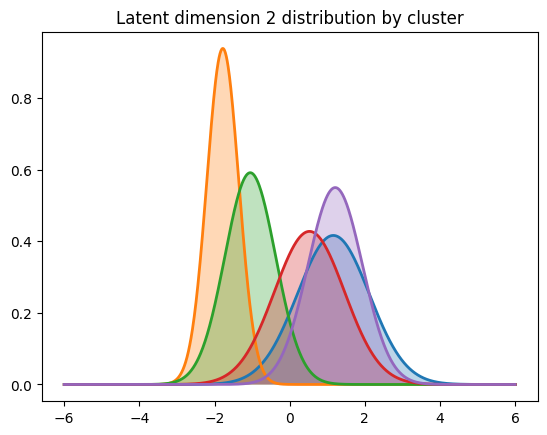

In [42]:
cluster_params_lv2 = {
    '1': {'mean': np.mean(label1['LV2']), 'variance': np.std(label1['LV2'])}, 
    '2': {'mean': np.mean(label2['LV2']), 'variance': np.std(label2['LV2'])}, 
    '3': {'mean': np.mean(label3['LV2']), 'variance': np.std(label3['LV2'])},
    '4': {'mean': np.mean(label4['LV2']), 'variance': np.std(label4['LV2'])},
    '5': {'mean': np.mean(label5['LV2']), 'variance': np.std(label5['LV2'])},
}

all_means = [p['mean'] for p in cluster_params_lv2.values()]
all_stds = [p['variance'] for p in cluster_params_lv2.values()]

##x_min = min(all_means) - 4 * max(all_stds)
#x_max = max(all_means) + 4 * max(all_stds)

x_values = np.linspace(-6, 6, 1000)

for name, params in cluster_params_lv2.items():
    mean = params['mean']
    std_dev = params['variance']
    y_values = norm.pdf(x_values, loc=mean, scale=std_dev)
    plt.plot(x_values, y_values, linewidth=2, label=name)
    plt.fill_between(x_values, y_values, alpha=0.3)
    plt.title('Latent dimension 2 distribution by cluster')

print('mean label 1:' +  str(np.mean(label1['LV2'])) + ', std label 1: ' + str(np.std(label1['LV2'])))
print('mean label 2:' +  str(np.mean(label2['LV2'])) + ', std label 2: ' + str(np.std(label2['LV2'])))
print('mean label 3:' +  str(np.mean(label3['LV2'])) + ', std label 3: ' + str(np.std(label3['LV2'])))
print('mean label 4:' +  str(np.mean(label4['LV2'])) + ', std label 4: ' + str(np.std(label4['LV2'])))
print('mean label 5:' +  str(np.mean(label5['LV2'])) + ', std label 5: ' + str(np.std(label5['LV2'])))

In [43]:
priors = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/CGMVAE/prior_distribution.csv')
priors.head()

,Dim1,Dim2,Component
0,2.148785,2.523779,4.0
1,2.162949,1.913216,4.0
2,-1.714854,1.388316,2.0
3,1.250710,0.197057,3.0
4,-0.680534,-2.007962,1.0


In [44]:
gmm_centers = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5_new.csv')
gmm_centers

,Unnamed: 0,center1,center2,center3,center4,center5
0,0,-2.322136,-1.287806,-0.253477,0.780852,1.815182
1,1,-1.774800,-0.733941,0.306919,1.347779,2.388638


In [45]:
gmm_centers.iloc[0, 1:]

center1   -2.322136
center2   -1.287806
center3   -0.253477
center4    0.780852
center5    1.815182
Name: 0, dtype: float64

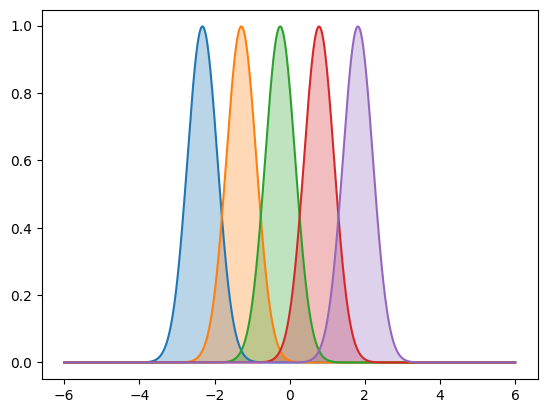

In [46]:
x_values = np.linspace(-6, 6, 1000)

for num in gmm_centers.iloc[0, 1:]:
    mean = float(num)
    std_dev = 0.4
    y_values = norm.pdf(x_values, loc=mean, scale=std_dev)
    plt.plot(x_values, y_values)
    plt.fill_between(x_values, y_values, alpha=0.3)

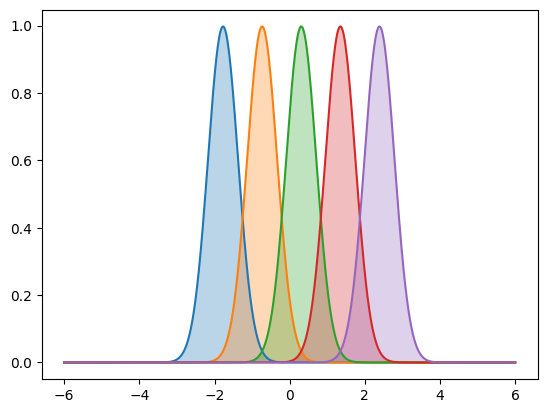

In [47]:
x_values = np.linspace(-6, 6, 1000)

for num in gmm_centers.iloc[1, 1:]:
    mean = float(num)
    std_dev = 0.4
    y_values = norm.pdf(x_values, loc=mean, scale=std_dev)
    plt.plot(x_values, y_values)
    plt.fill_between(x_values, y_values, alpha=0.3)

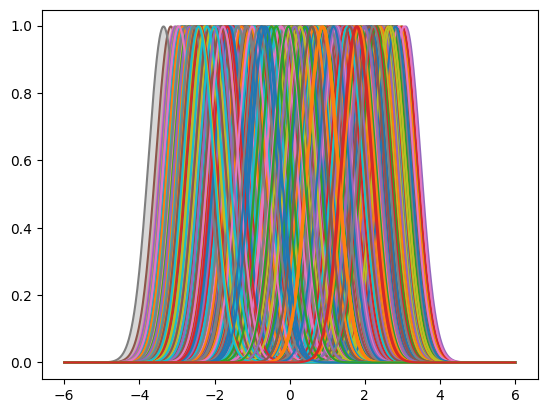

In [48]:
for num in priors['Dim1']:
    mean = num
    std = 0.02
    y_values = norm.pdf(x_values, loc=mean, scale=std_dev)
    plt.plot(x_values, y_values)
    plt.fill_between(x_values, y_values, alpha=0.3)

Text(0.5, 1.0, 'Prior approximated distribution for Dim1')

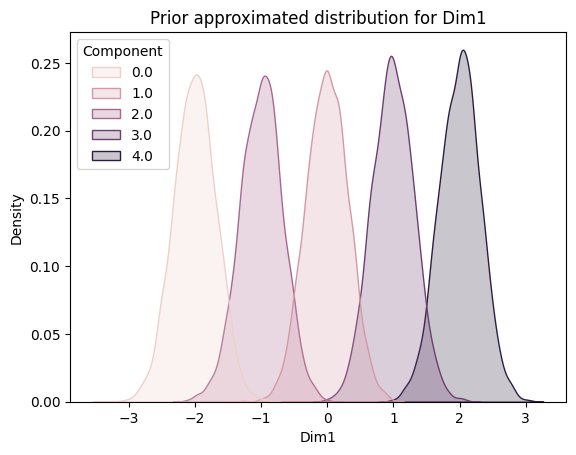

In [49]:
ax = sns.kdeplot(data=priors, x='Dim1', hue='Component', fill=True, bw_adjust=1)
ax.set_title('Prior approximated distribution for Dim1')

Text(0.5, 1.0, 'Prior approximated distribution for Dim2')

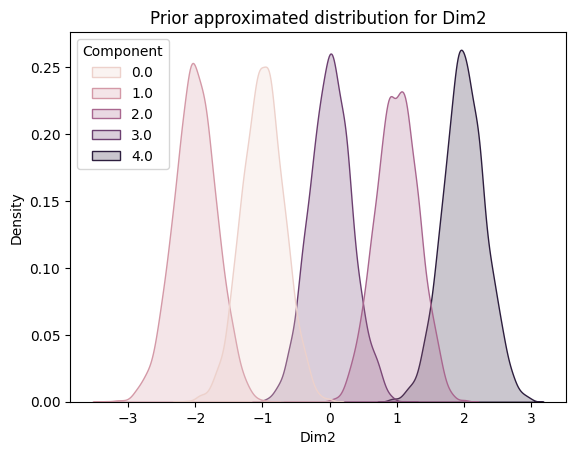

In [50]:
ax = sns.kdeplot(data=priors, x='Dim2', hue='Component', fill=True, bw_adjust=1)
ax.set_title('Prior approximated distribution for Dim2')

## Latent space with 5 latent dimensions

In [51]:
lv_epochs1000_dim5 = pd.read_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/results_DIET/CGMVAE_dim5_v2/latent_variables_epoch1000.csv')
lv_epochs1000_dim5

,LV1,LV2,LV3,LV4,LV5,labels,mouse_ids
0,-0.891556,5.561009,-5.232284,-22.574064,-3.269258,0,DO-40-2166
1,3.276296,6.455621,1.096373,-11.624786,4.320874,2,DO-2D-4012
2,15.366242,25.019520,15.512431,-0.506833,14.266158,2,DO-2D-4177
3,-2.536432,3.564408,-6.267589,-24.935354,-4.164485,0,DO-40-2041
4,11.519822,17.747171,-0.347831,-15.566242,2.082224,4,DO-AL-0139
...,...,...,...,...,...,...,...
932,-6.202507,2.484043,-4.001377,-25.531122,-5.329925,1,DO-20-1097
933,10.310848,9.949667,5.213844,-9.950603,4.755767,2,DO-2D-4079
934,4.471822,11.529593,-0.080993,-22.165620,3.072807,0,DO-40-2024
935,-5.695318,0.158414,-10.598497,-28.667217,-8.166290,1,DO-20-1138


In [52]:
cfc_latentdim5_merged = pd.merge(lv_epochs1000_dim5, cfc, left_on='mouse_ids', right_on='Mouse.ID')
cfc_latentdim5_merged

,LV1,LV2,LV3,LV4,LV5,labels,mouse_ids,Diet,Mouse.ID,CFC.24mo.Average
0,3.276296,6.455621,1.096373,-11.624786,4.320874,2,DO-2D-4012,2D,DO-2D-4012,70.13
1,15.366242,25.019520,15.512431,-0.506833,14.266158,2,DO-2D-4177,2D,DO-2D-4177,0.22
2,11.519822,17.747171,-0.347831,-15.566242,2.082224,4,DO-AL-0139,AL,DO-AL-0139,32.18
3,0.916364,5.494659,-4.013104,-26.889584,-1.926141,0,DO-40-2105,40,DO-40-2105,1.38
4,20.259783,18.165281,14.415266,-2.656757,13.627493,3,DO-1D-3136,1D,DO-1D-3136,61.02
...,...,...,...,...,...,...,...,...,...,...
499,10.745834,18.029362,1.217806,-13.915854,10.326515,4,DO-AL-0107,AL,DO-AL-0107,38.18
500,-6.202507,2.484043,-4.001377,-25.531122,-5.329925,1,DO-20-1097,20,DO-20-1097,45.38
501,4.471822,11.529593,-0.080993,-22.165620,3.072807,0,DO-40-2024,40,DO-40-2024,37.24
502,-5.695318,0.158414,-10.598497,-28.667217,-8.166290,1,DO-20-1138,20,DO-20-1138,78.58


In [53]:
# do dimensionality reduction to visualize latent space in 2D
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
tsne_epochs1000_dim5 = tsne.fit_transform(lv_epochs1000_dim5.iloc[:, :-2])

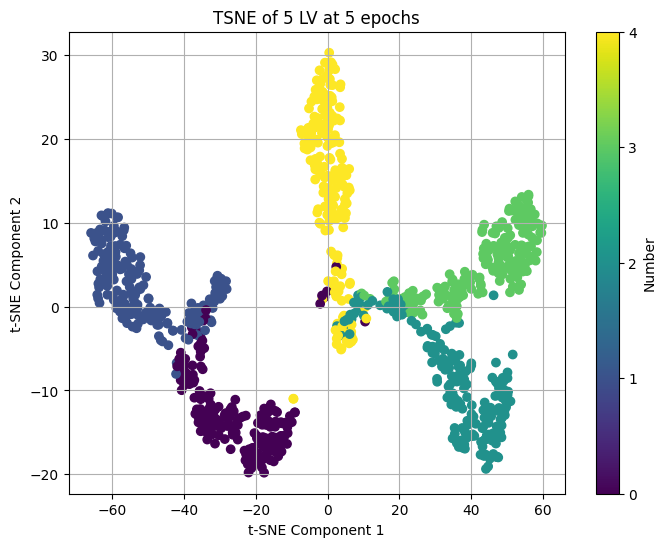

In [54]:
labels = lv_epochs1000_dim5.iloc[:, -2]
plt.figure(figsize=(8, 6))
scatter = plt.scatter(tsne_epochs1000_dim5[:, 0], tsne_epochs1000_dim5[:, 1], c=labels, cmap='viridis')
plt.title('TSNE of 5 LV at 5 epochs')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')    
plt.colorbar(scatter, ticks=np.unique(labels), label='Number')
plt.grid(True)
plt.show()

In [55]:
cfc_tsne_epochs1000_dim5 = tsne.fit_transform(cfc_latentdim5_merged.iloc[:, :-5])

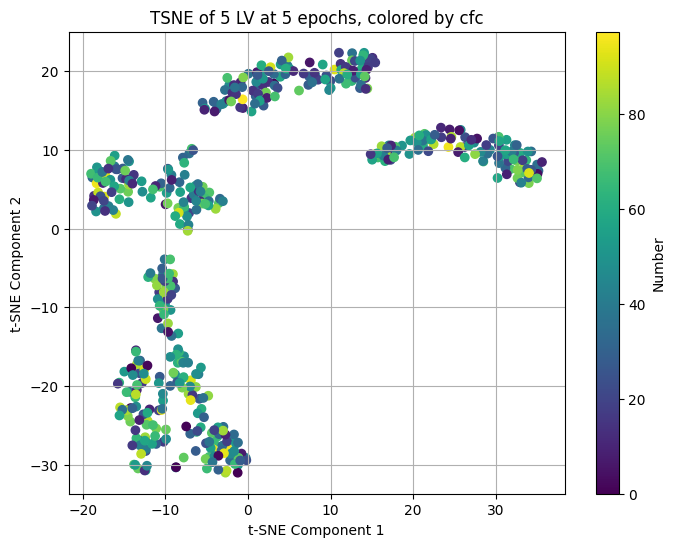

In [56]:
cfc_num = cfc_latentdim5_merged.iloc[:, -1]
plt.figure(figsize=(8, 6))
scatter = plt.scatter(cfc_tsne_epochs1000_dim5[:, 0], cfc_tsne_epochs1000_dim5[:, 1], c=cfc_num, cmap='viridis')
plt.title('TSNE of 5 LV at 5 epochs, colored by cfc')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.colorbar(scatter, label='Number')
plt.grid(True)
plt.show()

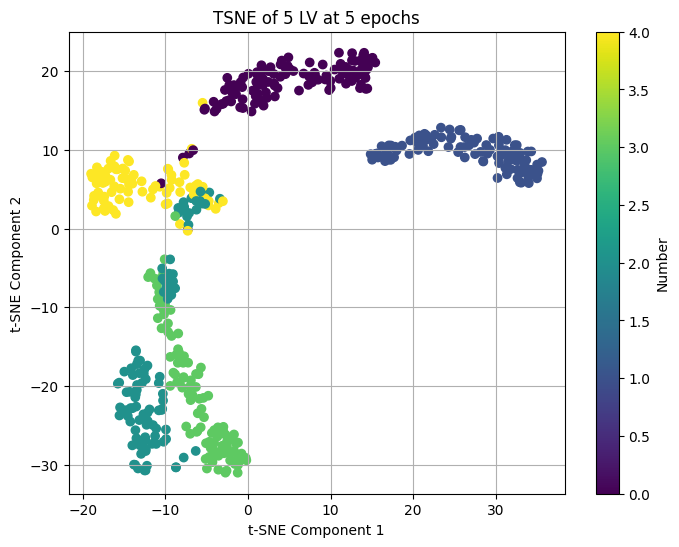

In [57]:
diet_labels = cfc_latentdim5_merged.iloc[:, -5]
plt.figure(figsize=(8, 6))
scatter = plt.scatter(cfc_tsne_epochs1000_dim5[:, 0], cfc_tsne_epochs1000_dim5[:, 1], c=diet_labels, cmap='viridis')
plt.title('TSNE of 5 LV at 5 epochs')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.colorbar(scatter, label='Number')
plt.grid(True)
plt.show()

In [58]:
cfc_latentdim5_merged   

,LV1,LV2,LV3,LV4,LV5,labels,mouse_ids,Diet,Mouse.ID,CFC.24mo.Average
0,3.276296,6.455621,1.096373,-11.624786,4.320874,2,DO-2D-4012,2D,DO-2D-4012,70.13
1,15.366242,25.019520,15.512431,-0.506833,14.266158,2,DO-2D-4177,2D,DO-2D-4177,0.22
2,11.519822,17.747171,-0.347831,-15.566242,2.082224,4,DO-AL-0139,AL,DO-AL-0139,32.18
3,0.916364,5.494659,-4.013104,-26.889584,-1.926141,0,DO-40-2105,40,DO-40-2105,1.38
4,20.259783,18.165281,14.415266,-2.656757,13.627493,3,DO-1D-3136,1D,DO-1D-3136,61.02
...,...,...,...,...,...,...,...,...,...,...
499,10.745834,18.029362,1.217806,-13.915854,10.326515,4,DO-AL-0107,AL,DO-AL-0107,38.18
500,-6.202507,2.484043,-4.001377,-25.531122,-5.329925,1,DO-20-1097,20,DO-20-1097,45.38
501,4.471822,11.529593,-0.080993,-22.165620,3.072807,0,DO-40-2024,40,DO-40-2024,37.24
502,-5.695318,0.158414,-10.598497,-28.667217,-8.166290,1,DO-20-1138,20,DO-20-1138,78.58


In [59]:
ymaze_speed_data_cleaned = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/ymaze_speed_data_cleaned.csv')
ymaze_speed_latentdim5_merged = pd.merge(cfc_latentdim5_merged, ymaze_speed_data_cleaned, left_on='mouse_ids', right_on='Mouse.ID')
ymaze_speed_latentdim5_merged

,LV1,LV2,LV3,LV4,LV5,labels,mouse_ids,Diet_x,Mouse.ID_x,CFC.24mo.Average,Diet_y,Mouse.ID_y,Ymaze.MeanSpeed.10mo
0,3.276296,6.455621,1.096373,-11.624786,4.320874,2,DO-2D-4012,2D,DO-2D-4012,70.13,2D,DO-2D-4012,0.022
1,15.366242,25.019520,15.512431,-0.506833,14.266158,2,DO-2D-4177,2D,DO-2D-4177,0.22,2D,DO-2D-4177,0.038
2,11.519822,17.747171,-0.347831,-15.566242,2.082224,4,DO-AL-0139,AL,DO-AL-0139,32.18,AL,DO-AL-0139,0.021
3,0.916364,5.494659,-4.013104,-26.889584,-1.926141,0,DO-40-2105,40,DO-40-2105,1.38,40,DO-40-2105,0.031
4,20.259783,18.165281,14.415266,-2.656757,13.627493,3,DO-1D-3136,1D,DO-1D-3136,61.02,1D,DO-1D-3136,0.008
...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,10.745834,18.029362,1.217806,-13.915854,10.326515,4,DO-AL-0107,AL,DO-AL-0107,38.18,AL,DO-AL-0107,0.017
500,-6.202507,2.484043,-4.001377,-25.531122,-5.329925,1,DO-20-1097,20,DO-20-1097,45.38,20,DO-20-1097,0.023
501,4.471822,11.529593,-0.080993,-22.165620,3.072807,0,DO-40-2024,40,DO-40-2024,37.24,40,DO-40-2024,0.031
502,-5.695318,0.158414,-10.598497,-28.667217,-8.166290,1,DO-20-1138,20,DO-20-1138,78.58,20,DO-20-1138,0.011


In [60]:
ymazespeed_tsne_epochs1000_dim5 = tsne.fit_transform(ymaze_speed_latentdim5_merged.iloc[:, :-8])

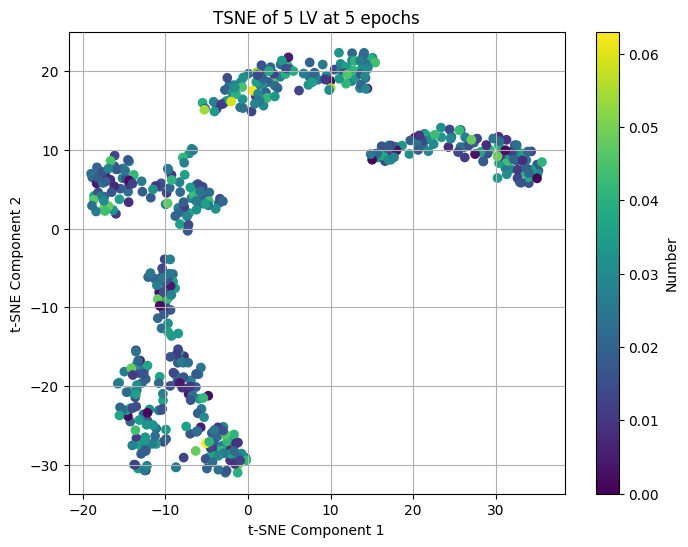

In [61]:
ymaze_speed_labels = ymaze_speed_latentdim5_merged.iloc[:, -1]
plt.figure(figsize=(8, 6))
scatter = plt.scatter(ymazespeed_tsne_epochs1000_dim5[:, 0], ymazespeed_tsne_epochs1000_dim5[:, 1], c=ymaze_speed_labels, cmap='viridis')
plt.title('TSNE of 5 LV at 5 epochs')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.colorbar(scatter, label='Number')
plt.grid(True)
plt.show()

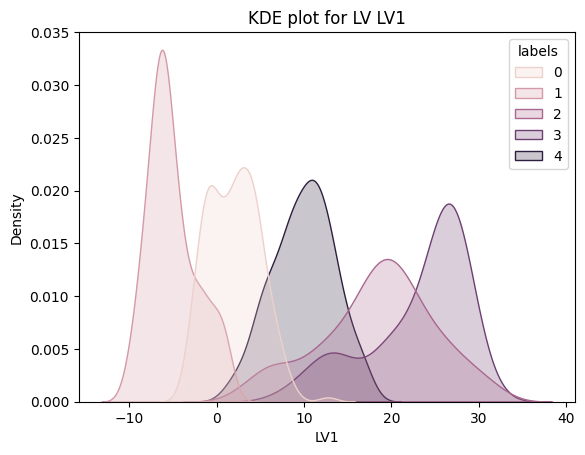

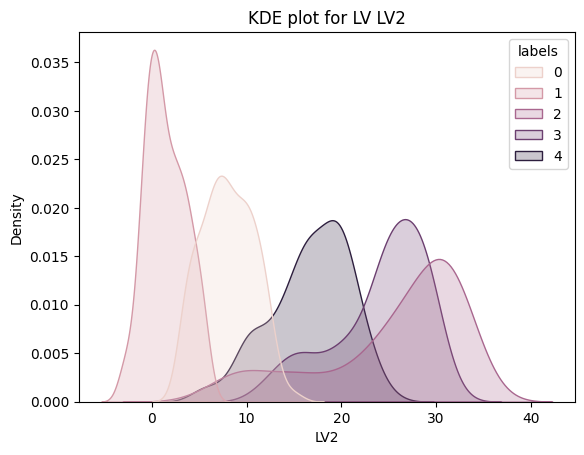

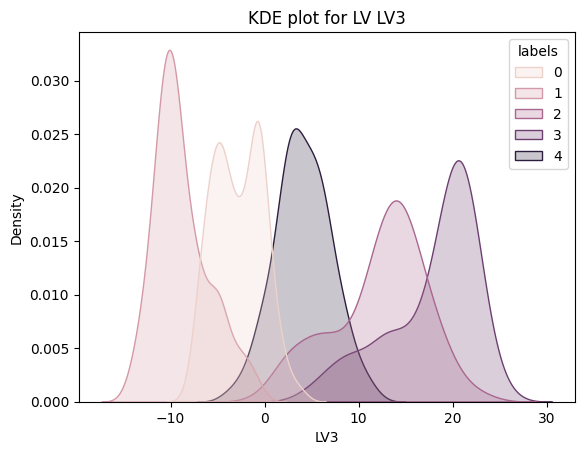

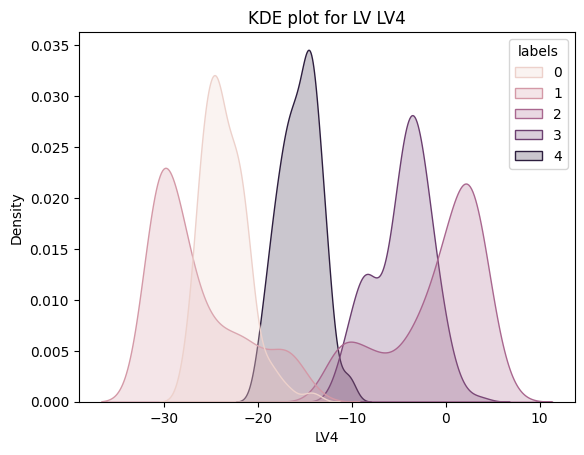

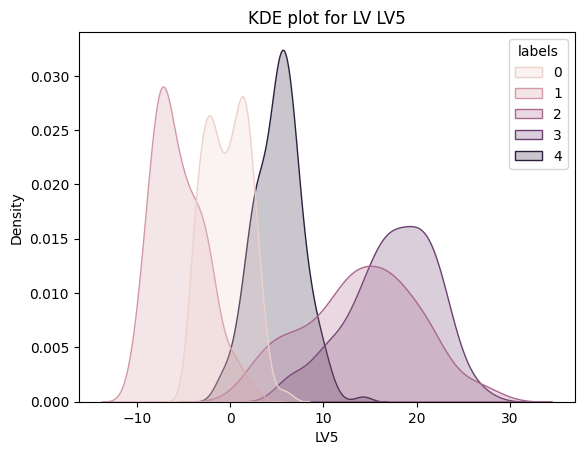

In [62]:
for lv in lv_epochs1000_dim5.iloc[:, :-2].columns:
    data = lv_epochs1000_dim5[[lv, 'labels']]
    sns.kdeplot(data=data, x=lv, hue='labels', fill=True)
    plt.title('KDE plot for LV ' + str(lv))
    plt.show()

## Plotting latent spaces using dimensionality reduction for > 2 latent variables

In [63]:
# do dimensionality reduction to visualize latent space in 2D
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
tsne_lv5 = tsne.fit_transform(lv_epochs5.iloc[:, :-1])

ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not 0      5
1      4
2      1
3      3
4      5
      ..
507    2
508    2
509    2
510    4
511    3
Name: labels, Length: 512, dtype: object

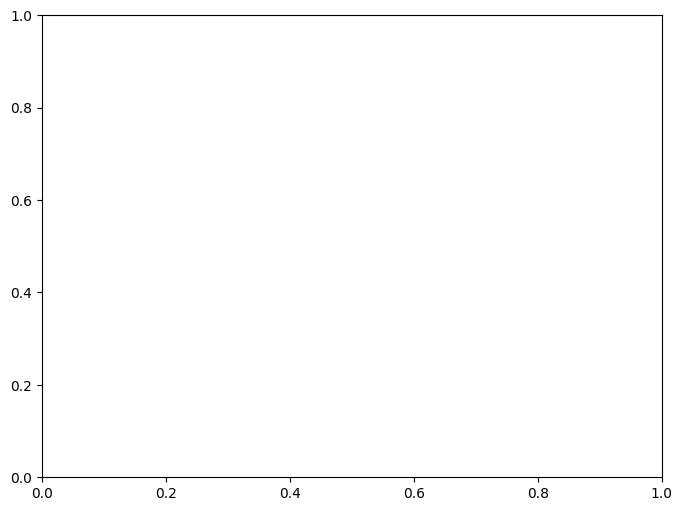

In [64]:
labels = lv_epochs5.iloc[:, -1]
plt.figure(figsize=(8, 6))
scatter = plt.scatter(tsne_lv5[:, 0], tsne_lv5[:, 1], c=labels, cmap='viridis')
plt.title('TSNE of 20 LV at 5 epochs')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.colorbar(scatter, ticks=np.unique(labels), label='Number')
plt.grid(True)
plt.show()

In [ ]:
tsne_lv10 = tsne.fit_transform(lv_epochs10.iloc[:, :-1])

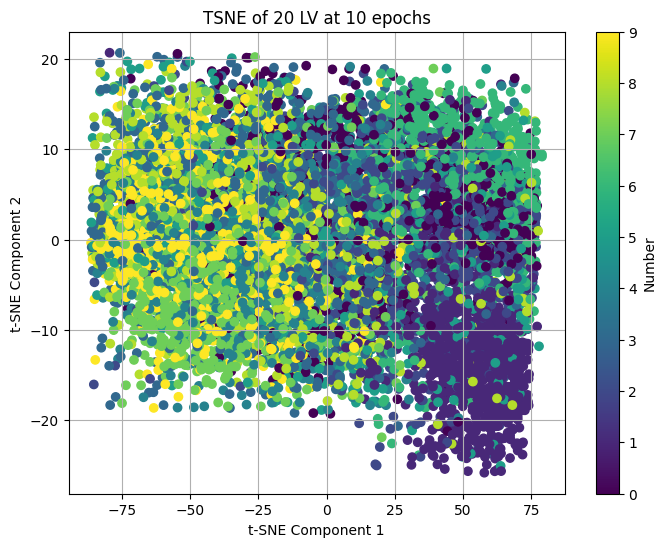

In [ ]:
labels = lv_epochs10.iloc[:, -1]
plt.figure(figsize=(8, 6))
scatter = plt.scatter(tsne_lv10[:, 0], tsne_lv5[:, 1], c=labels, cmap='viridis')
plt.title('TSNE of 20 LV at 10 epochs')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.colorbar(scatter, ticks=np.unique(labels), label='Number')
plt.grid(True)
plt.show()

In [ ]:
lv_epochs5.max().max(), lv_epochs5.min().min()

(9.974489, -11.674962)

In [ ]:
lv_epochs10.max().max(), lv_epochs10.min().min()

(9.0, -9.8912325)

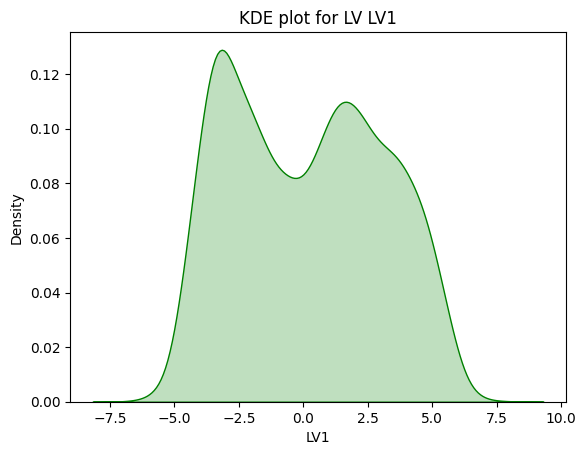

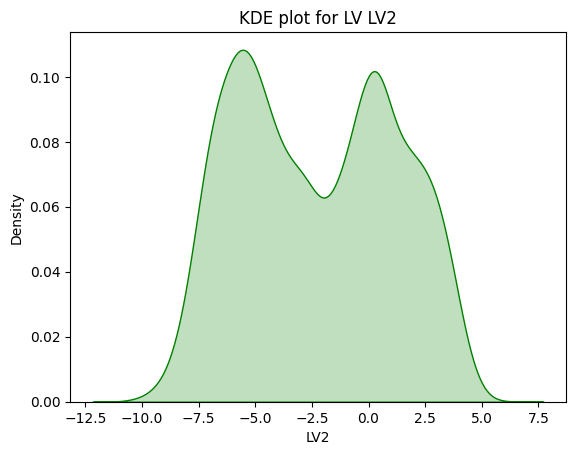

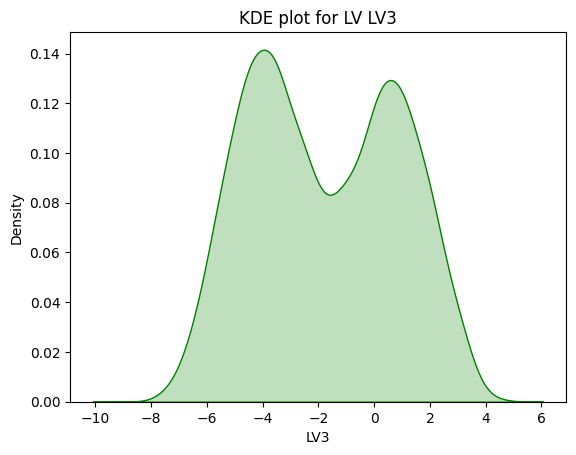

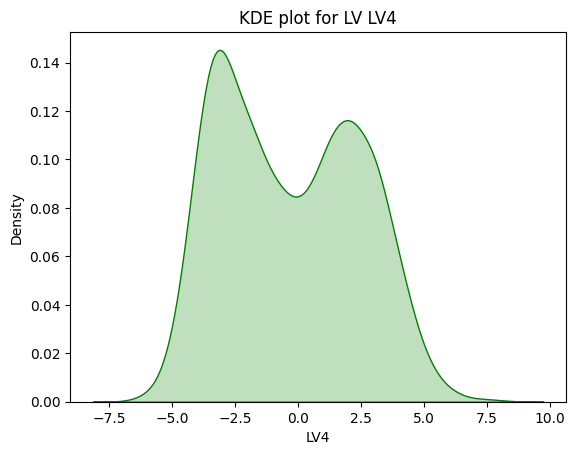

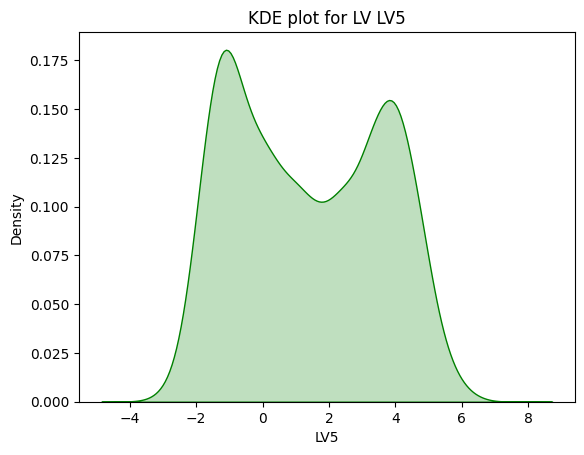

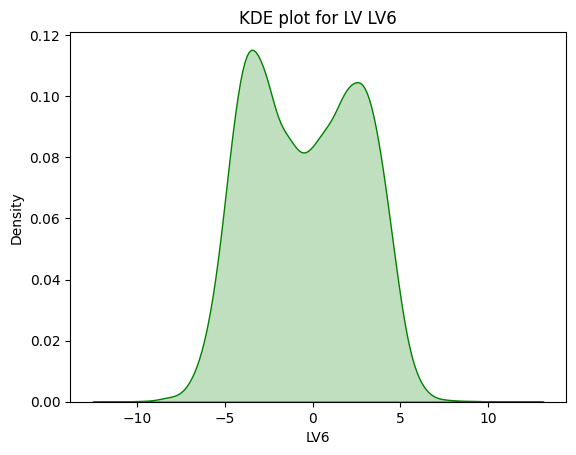

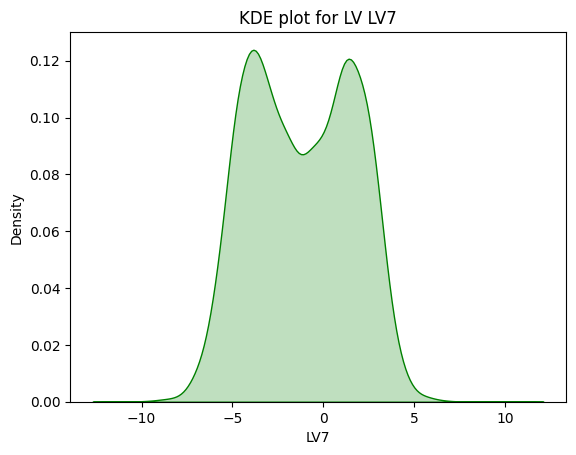

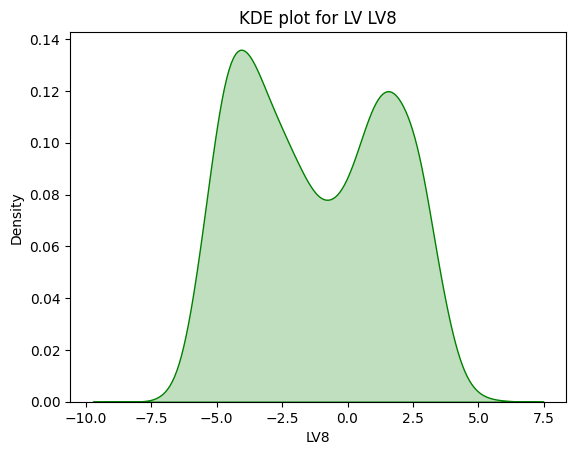

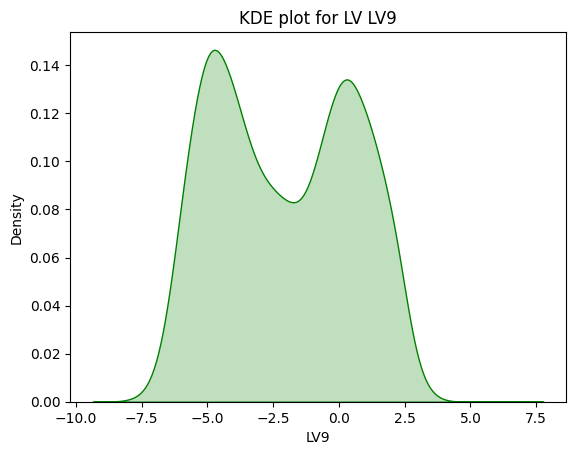

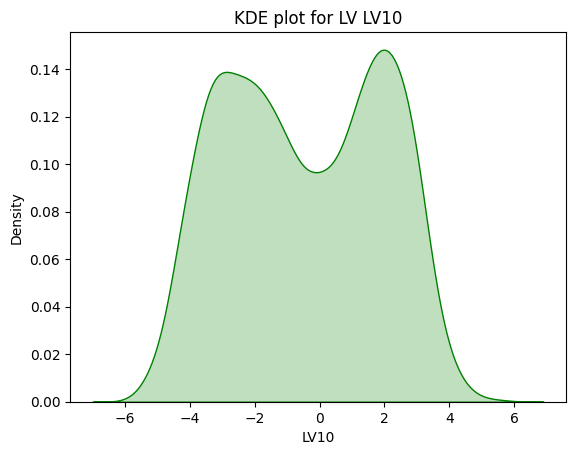

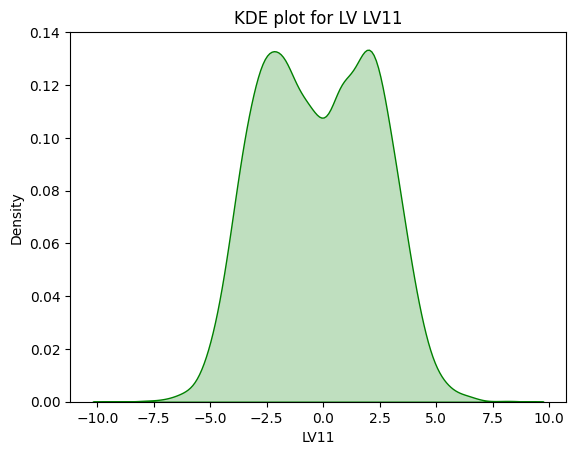

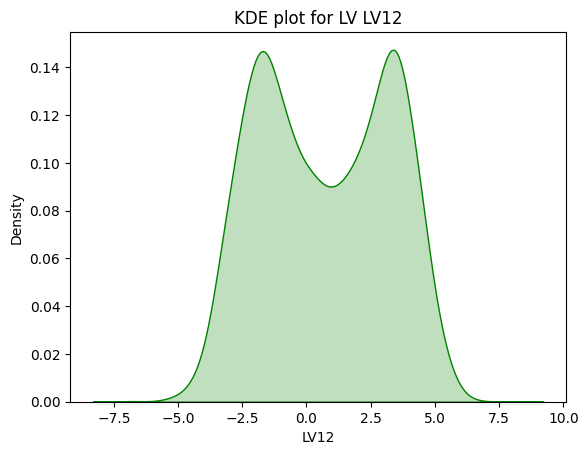

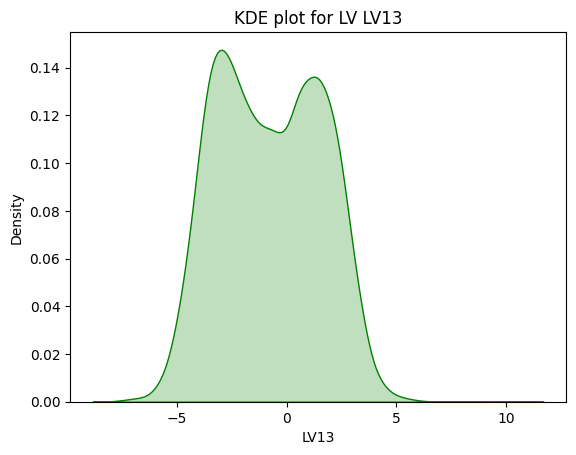

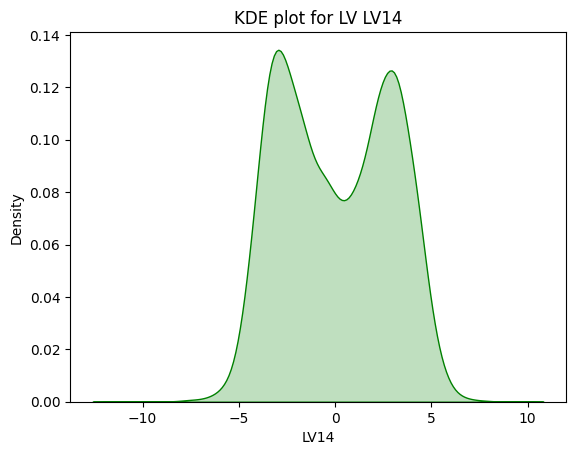

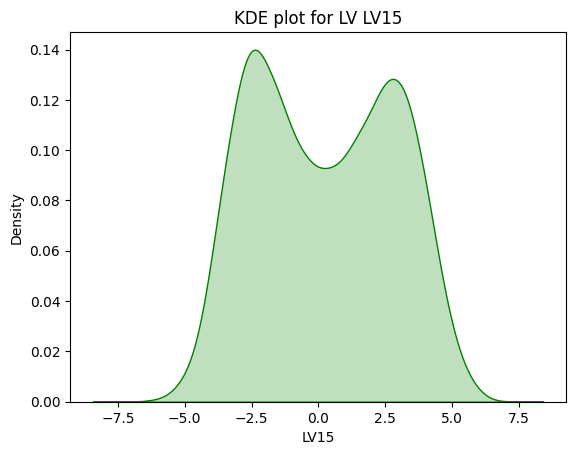

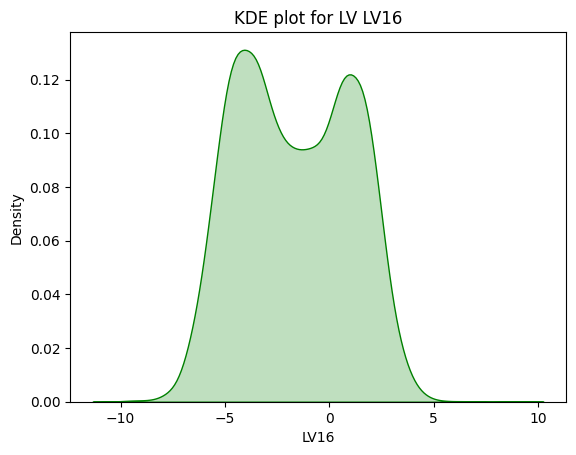

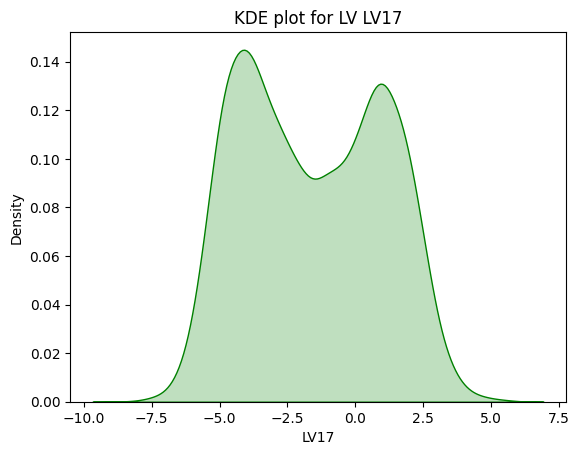

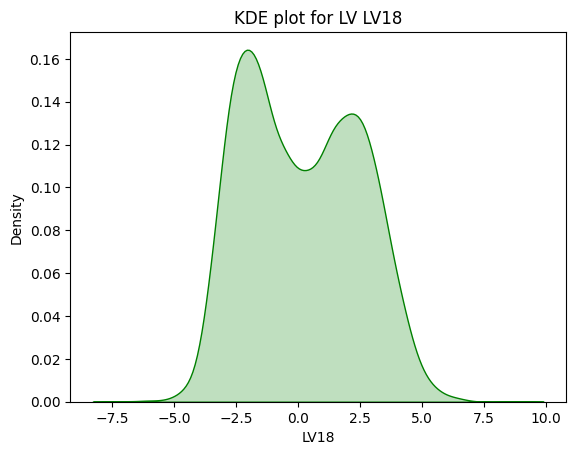

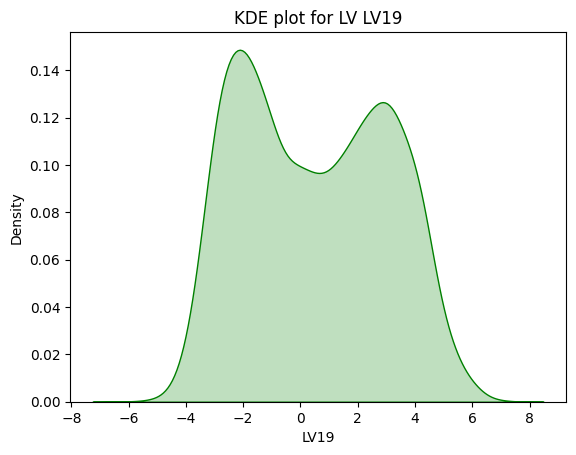

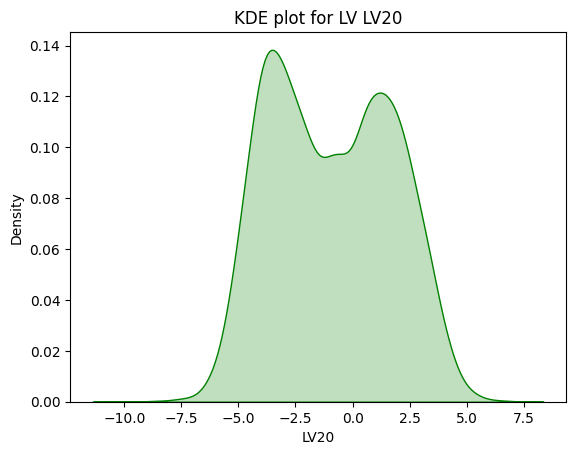

In [ ]:
# plot each latent variable distribution separately 
for lv in lv_epochs5.iloc[:, :-1].columns:
    data = lv_epochs5[lv]
    sns.kdeplot(x=data, color="green", fill=True)
    plt.title('KDE plot for LV ' + str(lv))
    plt.show()

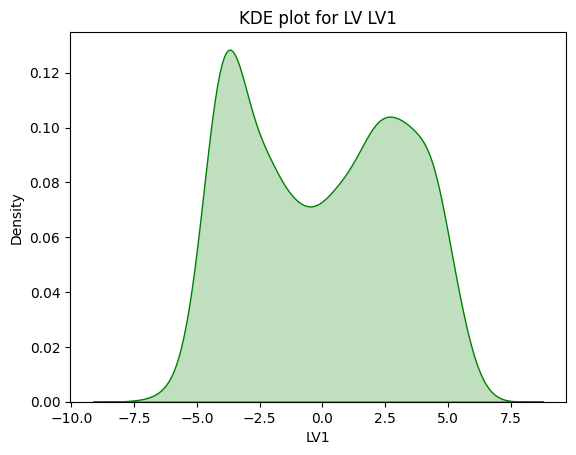

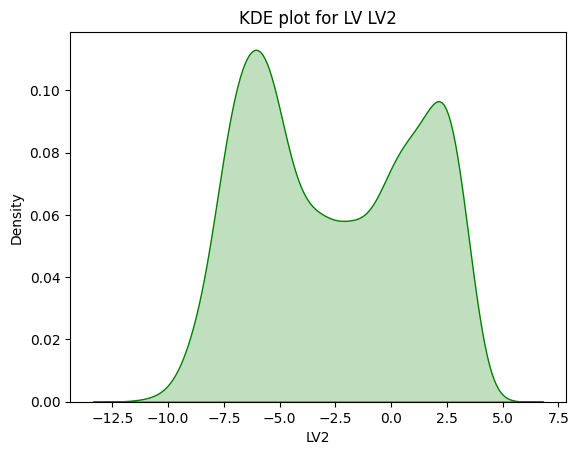

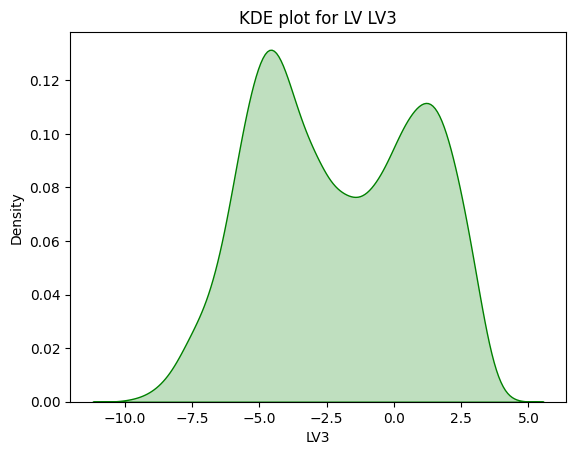

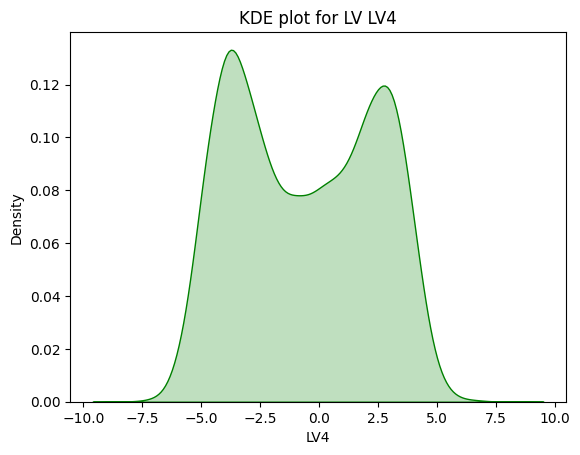

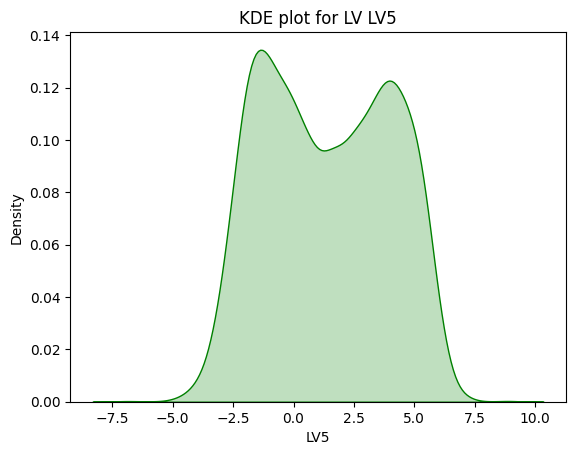

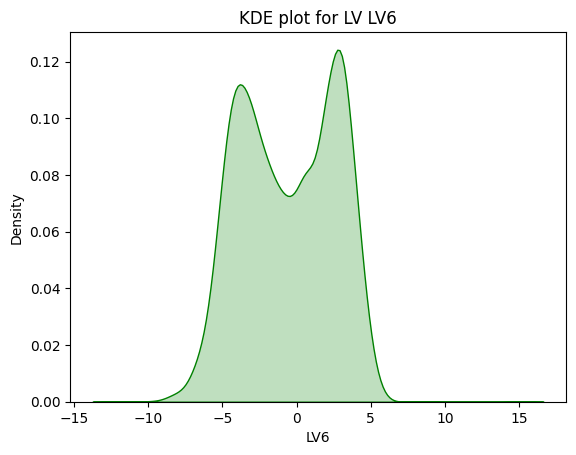

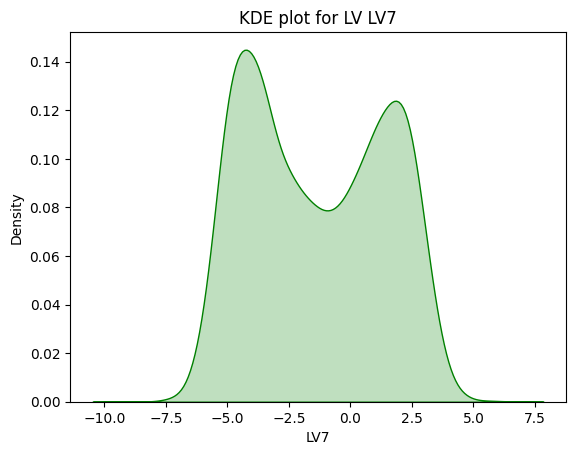

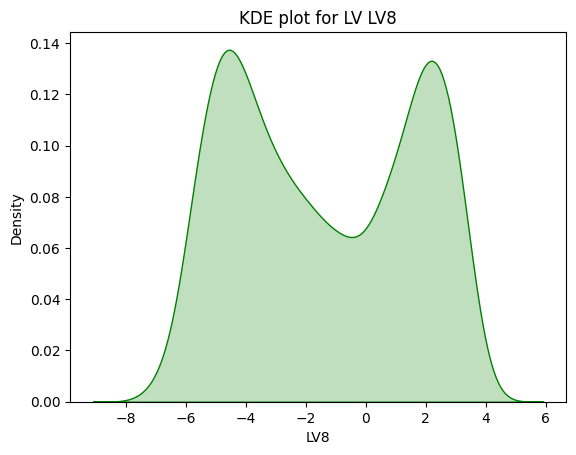

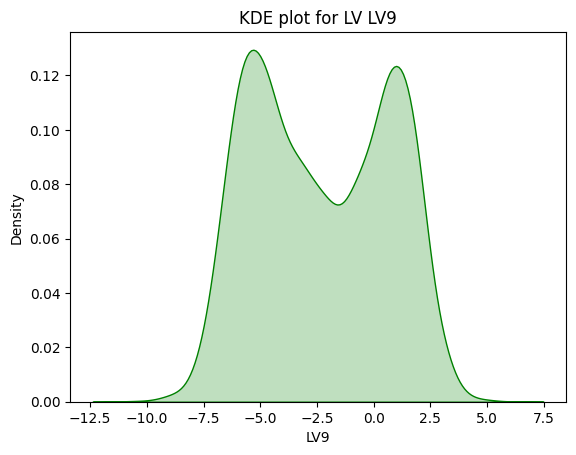

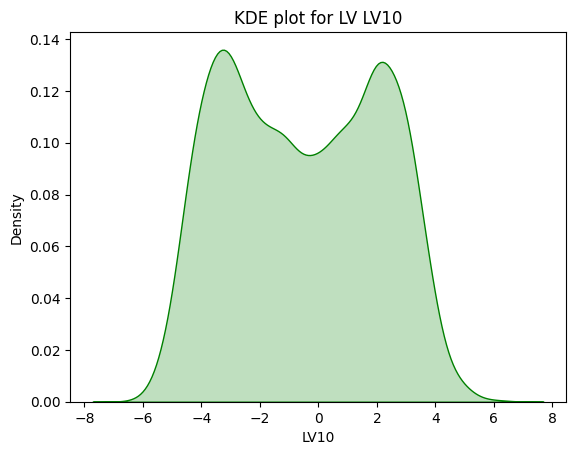

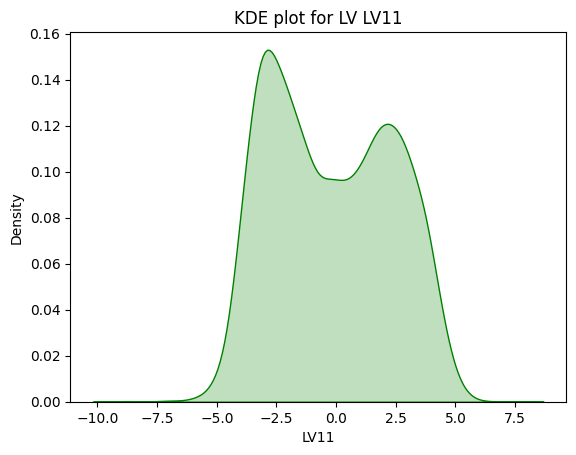

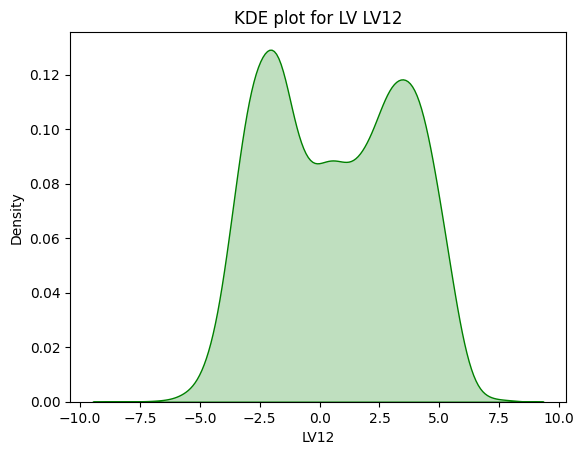

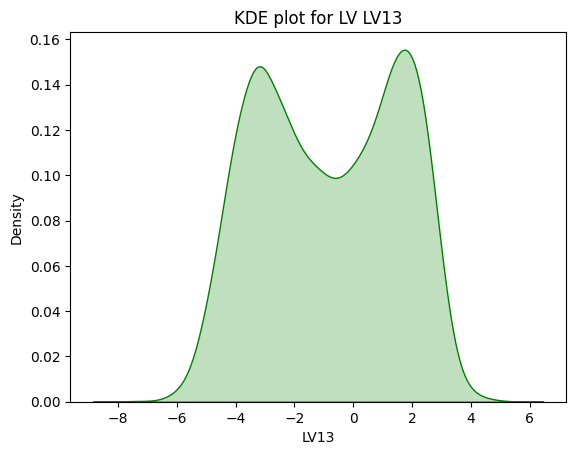

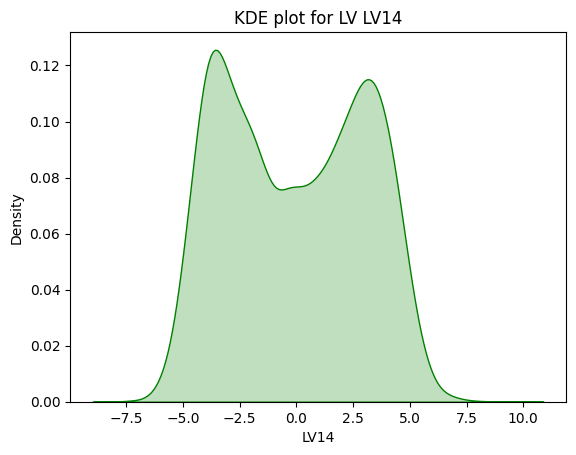

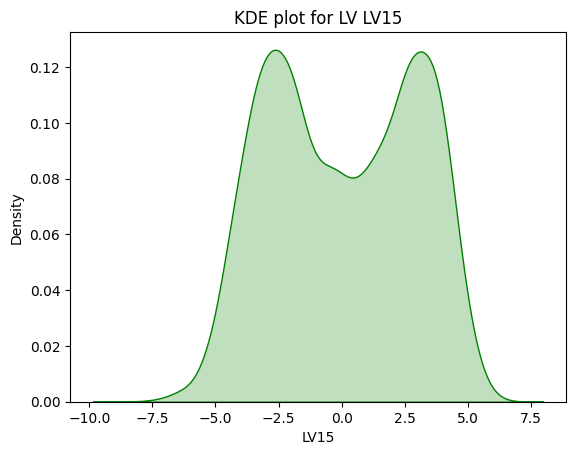

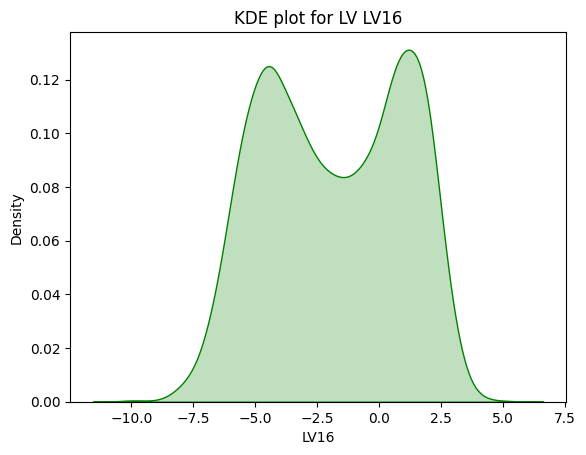

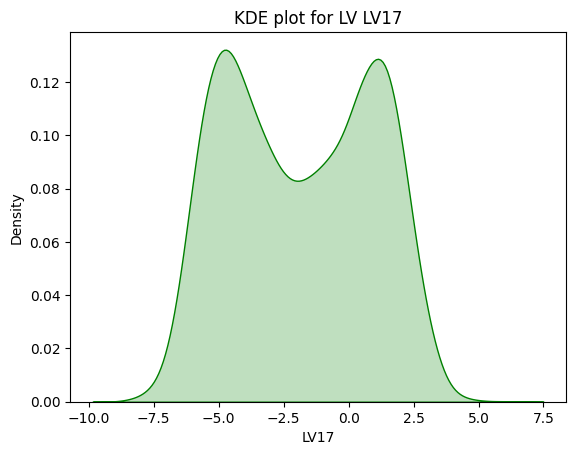

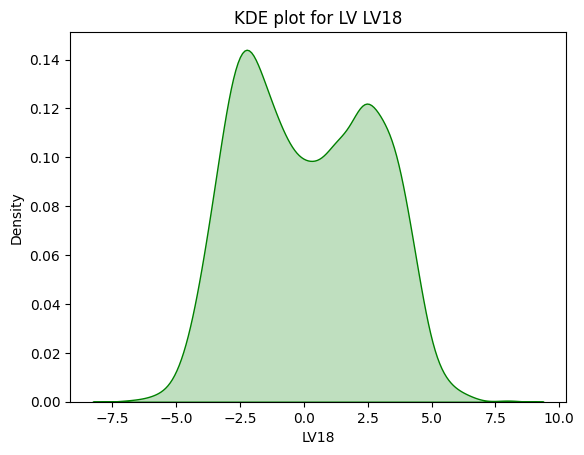

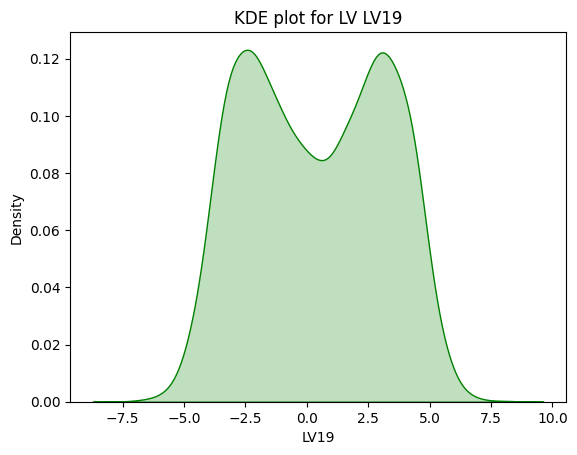

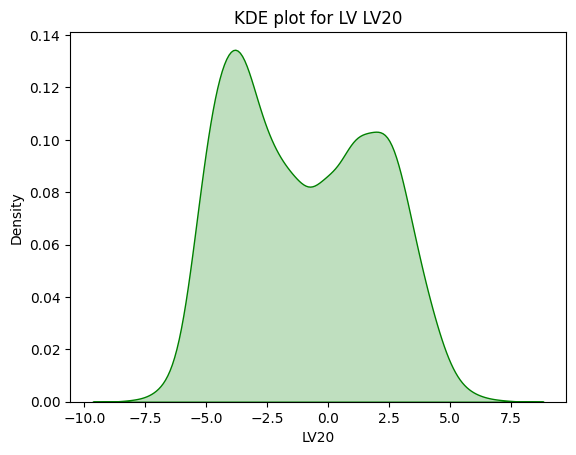

In [ ]:
# plot each latent variable distribution separately 
for lv in lv_epochs10.iloc[:, :-1].columns:
    data = lv_epochs10[lv]
    sns.kdeplot(x=data, color="green", fill=True)
    plt.title('KDE plot for LV ' + str(lv))
    plt.show()